# Atividade Avaliativa II - Final
##<span style="color:blue">Aluno: Gustavo Finger.</span>
### Prof. Bacalhau - Disciplina Análise Númerica.



# Crescimento de Microalga em Fotobiorreatores Compactos. Interpolação de valores e criação de equação para descrição do fenômeno Biológico

O fotobiorreator é um equipamento usado para crescimento celular. Foi usado um meio artificial do TIPO CHU (ABNT NBR 12648, 2004). Durante o experimento foram feitos a contagem de células em dias alternados, bem como a mediação da densidade de celular por meio das técnicas de Espectrofotometria (BRACHT & ISHII-IWAMOTO, 2003), semelhante ao que vemos na imagem a seguir.

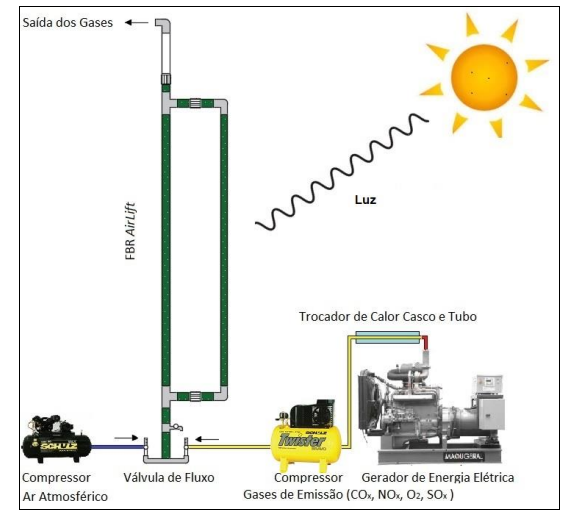

Como a contagem de células é um processo que demanda tempo, ela ocorreu em dias alternados durante o tempo de cultivo de 15 dias.  

Durante os dias em que não houve contagem de células, faz-se necessário interpolar os valores.

Será usado a técnica de interpolação de newton e de Lagrange para elaboração de um polinômio interpolador, bem como da técnica de spline cúbicas.

O trabalho é divido nas três etapas a seguir.

## 1-) Interpolação pelos Métodos de Lagrange e de Newton

### 1.1-) Montando os polinômios e verificando sua aplicabilidade para interpolação

## 2-) Interpolação Spline Cúbica

## 3-) Método dos mínimos quadrados para encontrar função que descreve a curva - Caso não Linear

## 4-) Cálculo do Erro e comentários

## 5-) Referências Bibliográficas



# Experimento I - Meio Chu (ABNT NBR 12648) - Injeção de $\frac{2L}{min}$ durante $\frac{1h}{dia}$ \
## O restando do tempo foi injetado ar comprimido a uma vazão de  $\frac{4L}{min}$ este ar comprimido é ar atmosférico

In [ ]:
# importando as bliotecas

import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import math

In [ ]:
pontos_células_I =   np.array([[1.0, 121.0],
                               [3.0, 358.0],
                               [5.0, 1730.0],
                               [7.0, 2115.0],
                               [9.0, 5610.0],
                               [11.0, 6325.0],
                               [13.0, 5850.0],
                               [15.0, 6350.0]
                              ])



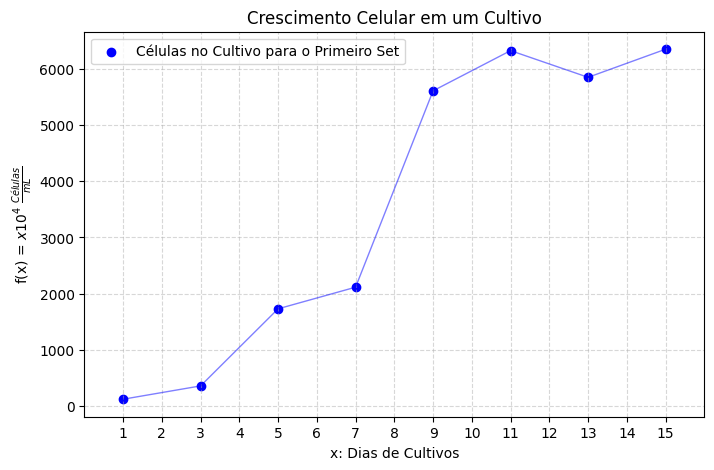

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pontos_células_I[:,0], pontos_células_I[:,1], color="blue", label="Células no Cultivo para o Primeiro Set")
plt.plot(pontos_células_I[:,0], pontos_células_I[:,1], linewidth=1, color="blue", alpha=0.5)
plt.xlim(0, 16)
plt.xticks(range(1, 16))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Crescimento Celular em um Cultivo")
plt.xlabel("x: Dias de Cultivos")
plt.ylabel(r"f(x) = $x 10^4$ $\frac{Células}{mL}$")
plt.show()

## Este experimento foi feito em Triplicata

In [ ]:
pontos_células_II =   np.array([[1.0, 153.0],
                                [3.0, 389.0],
                                [5.0, 1730.0],
                                [7.0, 2150.0],
                                [9.0, 5145.0],
                                [11.0, 6200.0],
                                [13.0, 5120.0],
                                [15.0, 6025.0]
                              ])

pontos_células_III =   np.array([ [1.0, 147.0],
                                  [3.0, 357.0],
                                  [5.0, 1725.0],
                                  [7.0, 2695.0],
                                  [9.0, 5310.0],
                                  [11.0, 6250.0],
                                  [13.0, 5100.0],
                                  [15.0, 6450.0]
                                ])

In [ ]:
x = pontos_células_I[:, 0]

# empilha os 3 conjuntos por coluna (cada linha = 3 valores de y)
ys = np.vstack([pontos_células_I[:,1],
                pontos_células_II[:,1],
                pontos_células_III[:,1]])

media = ys.mean(axis=0)
desvio = ys.std(axis=0)

# Plotando como os 3 sets da triplicata

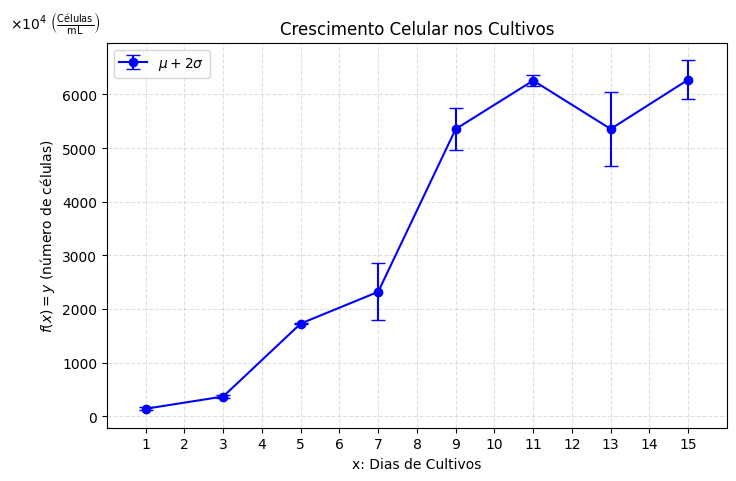

In [ ]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    x, media,
    yerr=2*desvio,
    fmt='o-',              # círculos + linha
    capsize=5,             # "tampas" das barras de erro
    color="blue",
    label=(r"$\mu + 2\sigma$")
)


plt.xlim(0, 16)
plt.xticks(range(1, 16))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.title("Crescimento Celular nos Cultivos")
plt.xlabel("x: Dias de Cultivos")
plt.ylabel(r"$f(x) = y $ (número de células)")
plt.text(
    -0.01, 1.02,
    r"$\times 10^{4}\ \left(\frac{\text{Células}}{\text{mL}}\right)$",
    transform=plt.gca().transAxes,
    ha='right', va='bottom'
)
plt.show()



In [ ]:
# Juntando os dados da triplicata em um uníco conjunto de pontos

cultivo = np.column_stack((x, media))

df_cultivo = pd.DataFrame(cultivo, columns=["Dias de cultivo", "Células no Meio"]).round(2)

print(df_cultivo)

   Dias de cultivo  Células no Meio
0              1.0           140.33
1              3.0           368.00
2              5.0          1728.33
3              7.0          2320.00
4              9.0          5355.00
5             11.0          6258.33
6             13.0          5356.67
7             15.0          6275.00


# Método de Newton


$P_n = f[x_0]+(x-x_0).f[x_0,x_1] + (x-x_0).((x-x_1)).f[x_0,x_1,x_2]+....  $

Cada termo novo cada termo novo multiplica o anterior por $(x - x_{k-1})$


In [ ]:
# Polinômio de Newton para Interpolação

In [ ]:
def diferencas_divididas(pontos):

      # T- tabela: matriz (n x n) onde a coluna 0 são os y, e colunas que seguem são as diferenças
      # coef: vetor contendo os coeficientes da forma de Newton (f[x0], f[x0,x1], f[x0,x1,x2], ...)

    pts = np.array(pontos, dtype=float)
    n = len(pts)
    x = pts[:, 0] # pega os valores de x no array pontos - argumento da função
    y = pts[:, 1] # pega os valores de y no array pontos - argumento da função

    # inicializa tabela: cada coluna k contém diferenças de ordem k (col 0 = x e col 1 = y) -> igual ao livro da prof. Marcia

    T = np.zeros((n, n+1), dtype=float)
    T[:, 0] = x
    T[:, 1] = y


    for j in range(2, n+1):
        for i in range(n - j +1):
            numerador = T[i + 1, j - 1] - T[i, j - 1]
            denominador = x[i + j - 1] - x[i]
            if denominador == 0:
                raise ZeroDivisionError(f"pontos com x's iguais: x[{i}] = x[{i+j}] = {x[i]}")
            T[i, j] = numerador / denominador


    # coeficientes de Newton são T[0,0], T[0,1], T[0,2], ...
    coef = T[0, 1:n + 1].copy()
    return T, coef

In [ ]:
# tabela de diferenças e coef
T, coef = diferencas_divididas(cultivo)

# gera nomes das colunas dinamicamente
n = len(cultivo)

print("Tabelosa das Diferenças divididas")
print("-----------------------------------")
colunas = ["x", "f[x]<->Ordem 0"] + [f"Ordem {i}" for i in range(1, n)]

#colunas= colunas = ["x", "f[x]", "ordem 1", "ordem 2", "ordem 3", "ordem 4", "ordem 5"]
tabela = pd.DataFrame(np.round(T, 3), columns=colunas)

pd.set_option('display.expand_frame_repr', False) # usei só para mostrar toda a tabela.

print(tabela)

colunas_2 = ["Coeficientes"]
coeficientes = pd.DataFrame(np.round(coef, 3), columns=colunas_2)
print("-----------------------------------")
print(coeficientes)


Tabelosa das Diferenças divididas
-----------------------------------
      x  f[x]<->Ordem 0   Ordem 1  Ordem 2  Ordem 3  Ordem 4  Ordem 5  Ordem 6  Ordem 7
0   1.0         140.333   113.833  141.583  -39.611   13.316   -3.359    0.555   -0.062
1   3.0         368.000   680.167  -96.083   66.917  -20.279    3.304   -0.310    0.000
2   5.0        1728.333   295.833  305.417  -95.312   12.765   -0.418    0.000    0.000
3   7.0        2320.000  1517.500 -266.458    6.806    8.589    0.000    0.000    0.000
4   9.0        5355.000   451.667 -225.625   75.521    0.000    0.000    0.000    0.000
5  11.0        6258.333  -450.833  227.500    0.000    0.000    0.000    0.000    0.000
6  13.0        5356.667   459.167    0.000    0.000    0.000    0.000    0.000    0.000
7  15.0        6275.000     0.000    0.000    0.000    0.000    0.000    0.000    0.000
-----------------------------------
   Coeficientes
0       140.333
1       113.833
2       141.583
3       -39.611
4        13.316
5     

# Construção do Polinômio de Newton

In [ ]:
def constroi_polinomio_newton(pontos, coef, mostrar_tabela=False):

    x = sp.Symbol('x')
    x_vals = pontos[:, 0]
    n = len(coef)
    P = coef[0]
    termo = 1 # cuidar porque vai ser uma multiplicação e não podemos começar com zero

    iteracoes = [] # vamos tentar guardar as iterções - [k]	[termo construído]	[coef[k]]	[termo adicionado a P]

    iteracoes.append({
          "k": 0,
          "termo construído": str(termo),
          "coef[k]": f"{coef[0]:.4f}",
          "termo adicionado a P": str(sp.N(sp.expand(coef[0] * termo), 4))
      })


    for k in range(1, n): #temos que começar em zero porque já começamos usando  P = coef[0]
        termo = termo * (x - x_vals[k - 1]) # estes são os x's...
        P = P + coef[k] * termo

        # salva cada passo no DataFrame iteracoes
        iteracoes.append({
            "k": k,
            "termo construído": str(termo),
            "coef[k]": round(coef[k], 3),
            "termo adicionado a P": str(sp.N(sp.expand(coef[k] * termo), 3)) # mostrando 3 casas somente
                         })

    P = sp.expand(P)
    P_simbolico = sp.N(P, 3)  # Mostra o valor simbólico e arredonda a 3 casas decimais
    P_func = sp.lambdify(x, P_simbolico, 'numpy') # função para podermos avaliar em qualque ponto de newton.

    if mostrar_tabela:
        iteracoes_df = pd.DataFrame(iteracoes)

        return P_simbolico, P_func, iteracoes_df
    else:
        return P_simbolico, P_func

In [ ]:
T, coef = diferencas_divididas(cultivo)

P_simbolico_normal, P_func_normal = constroi_polinomio_newton(cultivo, coef, mostrar_tabela=False)


print("Polinômio simbólico de Newton")
print("------------------------")
P_simbolico_normal

Polinômio simbólico de Newton
------------------------


-0.0618*x**7 + 3.58*x**6 - 83.5*x**5 + 999.0*x**4 - 6.51e+3*x**3 + 2.25e+4*x**2 - 3.66e+4*x + 1.97e+4

In [ ]:
# Testando a Função
P_func_normal(1)

9.018199999998615

# Plotagem da Função

In [ ]:
def plotar_funcao(f, xmin, xmax, pontos=10):
    # Gera 'pontos' valores igualmente espaçados no intervalo
    x = np.arange(xmin, xmax + 0.5, 0.5)
    y = [f(valor) for valor in x]

    plt.figure(figsize=(8, 5))
    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x, y, label="f(x)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Gráfico da função do Polinômio de Newton")
    plt.show()

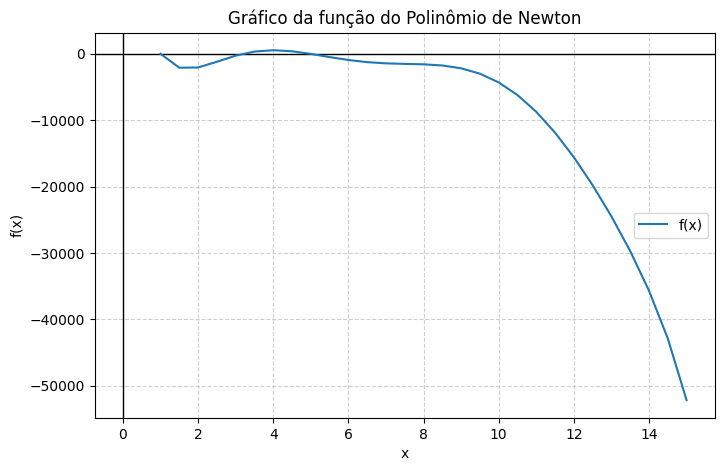

In [ ]:
plotar_funcao(P_func_normal,1,15)

In [ ]:
def lagrange_funcao_polinomial(pontos):

    # x é o valor do ponto que se quer interpolar.
    x = sp.Symbol('x')

    n = len(pontos)

    P = 0

    for k in range(n):
        xk, yk = pontos[k]

        # polinômio base L_i(k)
        Lk = 1.0 # cuidar, pois é uma multiplicação
        for j in range(n):
            if j != k:
                xj = pontos[j, 0]
                Lk = Lk* ((x - xj) / (xk - xj))

        P = P +  yk * Lk

    # Expande e arredonda coeficientes a 3 casas decimais
    P = sp.expand(P)
    P = sp.N(P, 4)  # arredonda para 4 casas decimais

    # cria função numérica para usar no matplotlib
    P_func = sp.lambdify(x, P, 'numpy')


    return P, P_func # para dar a função expandida.

In [ ]:
P_simbolico, P_func = lagrange_funcao_polinomial(cultivo)

print("Polinômio simbólico de Lagrange:")
print("------------------------")
P_simbolico

Polinômio simbólico de Lagrange:
------------------------


-0.06182*x**7 + 3.584*x**6 - 83.5*x**5 + 998.7*x**4 - 6505.0*x**3 + 2.254e+4*x**2 - 3.656e+4*x + 1.974e+4

In [ ]:
#y = lagrange_funcao_polinomial(cultivo)
#x = sp.Symbol('x')
#y = sp.lambdify(x, y, 'numpy')
#print(f"O valor da função é: {y(10):.4f}")

In [ ]:
def plotar_funcao_lagrange(f, xmin, xmax, pontos=10):
    # Gera 'pontos' valores igualmente espaçados no intervalo
    x = np.arange(xmin, xmax + 0.5, 0.5)
    y = [f(valor) for valor in x]

    plt.figure(figsize=(8, 5))
    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x, y, label="polinômio y(dia)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.xlabel("Dias de Cultivo")
    plt.ylabel(r"Células $(x 10^4)/mL$")
    plt.title("Gráfico da função do Polinômio de Lagrange")
    plt.show()

In [ ]:
P_func(10)


5940.0

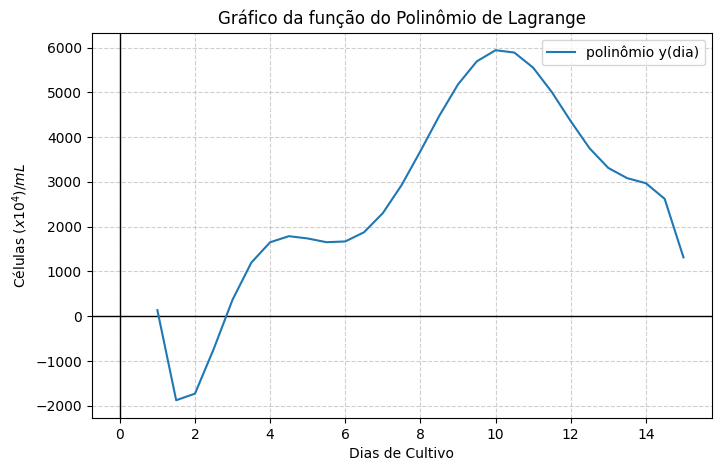

In [ ]:
plotar_funcao_lagrange(P_func,1,15)

## Percebe-se que a geração de um Polinômio de Lagrange ou de Newton não são as melhores técnicas para utilização de interpolação em cultivos de microalgas.

# Spline Cúbica

$S_k(x) = a_k(x-x_k)^3 + b_k(x-x_k)^2 + c_k(x-x_k) + d_k $, k = 1,2,...n

n polinômios de Grau 3

Condições:


$i)S_i(x)=s_k(x) \quad \text{para} \quad x \in [x_{k-1}, x_k]$


$ii)S_i(x_i)=f(x_i) , i= 0,1,...,n$


$iii)s_k(x_k)=s_{k+1}(x_k) \quad k= 1,2,...,n$


$iv)s_k'(x_k)=s_{k+1}'(x_k) \quad k= 1,2,...,n$

$v)s_k''(x_k)=s_{k+1}''(x_k) \quad k= 1,2,...,n$

Precisaremos da função de Eliminação de Gauss para a resolução da Spline Cúbica.

In [ ]:
def eliminacao_gauss(A, b, mostrar_g=False):

    n = len(b)  # número de equações

    operacoes = 0

    # Etapa de eliminação
    for k in range(n - 1):
        for i in range(k + 1, n):
            multiplicador = A[i][k] / A[k][k]
            operacoes = operacoes + 1
            A[i][k] = 0.0
            for j in range(k, n):
                A[i][j] = A[i][j] - multiplicador * A[k][j]
                operacoes = operacoes + 2 # são duas operações aqui, 1 mutiplicação e uma subtração
            b[i] = b[i] - multiplicador * b[k] # CUIDAR COM A INDEXAÇÃO, porque está errado no livro da Marcia.
            operacoes = operacoes + 2     # são duas operações aqui, 1 mutiplicação e uma subtração

    # Substituição retroativa
    x = [0] * n
    x[n - 1] = b[n - 1] / A[n - 1][n - 1]

    for k in range(n - 2, -1, -1):
        soma = 0
        for j in range(k + 1, n):
            soma = soma + A[k][j] * x[j]
        x[k] = (b[k] - soma) / A[k][k]

    # resultado
    if mostrar_g:
      print("A solução do nosso sistema é:")
      for i in range(n):
        print(f"g[{i+1}] = {x[i]:.4f}")

      print(f"Número de operações = {operacoes}")

      return np.array(x)
    else:
      return np.array(x)

In [ ]:
def spline_cubica(pontos):

    x_vals = pontos[:, 0]
    y_vals = pontos[:, 1]
    n = len(x_vals)

    # Passo 1: calcular h_i = x_{i+1} - x_i
    h = np.diff(x_vals)

    # Passo 2: montar matriz A (tridiagonal) e vetor b
    A = np.zeros((n - 2, n - 2))
    b = np.zeros(n - 2)

    for i in range(1, n - 1):
        if i - 2 >= 0:
            A[i - 1, i - 2] = h[i - 1]
        A[i - 1, i - 1] = 2 * (h[i - 1] + h[i])
        if i <= n - 3:
            A[i - 1, i] = h[i]
        b[i - 1] = 6 * ((y_vals[i + 1] - y_vals[i]) / h[i] - (y_vals[i] - y_vals[i - 1]) / h[i - 1])

    # Passo 3: resolver sistema para M_1, ..., M_{n-2}
    M_internos = eliminacao_gauss(A.tolist(), b.tolist(), mostrar_g=False)
    M = np.concatenate(([0], M_internos, [0]))  # spline

    # Passo 4: construir funções S_i(x)
    x = sp.Symbol('x')
    splines_simb = []
    splines_func = []

    for i in range(1, n):
        h_i = h[i - 1]
        S_i = (
            M[i - 1] * (x_vals[i] - x)**3 / (6 * h_i)
            + M[i] * (x - x_vals[i - 1])**3 / (6 * h_i)
            + (y_vals[i - 1] - M[i - 1] * h_i**2 / 6) * (x_vals[i] - x) / h_i
            + (y_vals[i] - M[i] * h_i**2 / 6) * (x - x_vals[i - 1]) / h_i
        )
        splines_simb.append(sp.simplify(S_i))
        splines_func.append(sp.lambdify(x, S_i, 'numpy'))

    return M, splines_simb, splines_func

In [ ]:
M, spline_cubica_simbolo, s_cubica_func =spline_cubica(cultivo)


In [ ]:
def spline_cubica_global(pontos, splines_func):

    #Retorna uma função global contínua que avalia a spline cúbica


    x_vals = pontos[:, 0]

    def S_global(x):
        x = np.array(x, ndmin=1)  # garante array
        y = np.zeros_like(x, dtype=float)
        for i in range(1, len(x_vals)):
            mask = (x >= x_vals[i-1]) & (x <= x_vals[i])
            if np.any(mask):
                y[mask] = splines_func[i-1](x[mask])
        return y

    return S_global

# Plotando os valores de S_func (Spline Cúbica Criada com as Células)

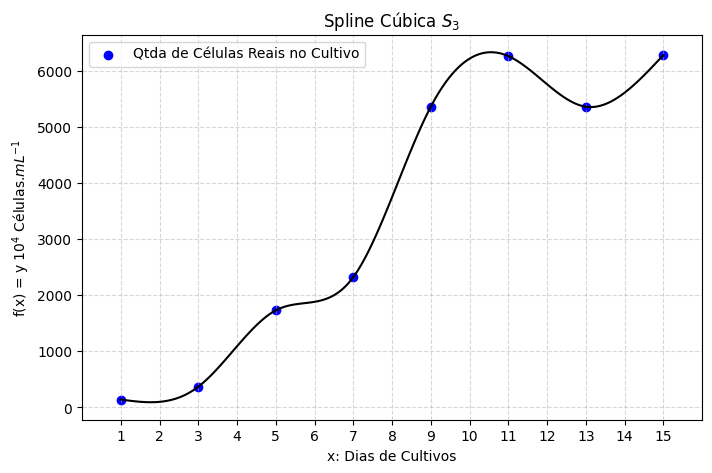

In [ ]:
# Testantando
x = sp.Symbol('x')
plt.figure(figsize=(8, 5))

for i in range(1, len(cultivo[:,0])):
    x_vals_intervalo = np.linspace(cultivo[i-1,0], cultivo[i,0], 50)
    y_vals_intervalo = [
        float(spline_cubica_simbolo[i-1].subs(x, val)) for val in x_vals_intervalo
    ]
    plt.plot(x_vals_intervalo, y_vals_intervalo, color="black")

plt.scatter(cultivo[:,0], cultivo[:,1], color="blue", label="Qtda de Células Reais no Cultivo")
plt.title(r"Spline Cúbica $S_{3}$")
plt.grid(True, linestyle='--', alpha=0.6)

plt.xlim(0, 16)
plt.xticks(range(1, 16))

plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("x: Dias de Cultivos")
plt.ylabel(r"f(x) = y $ 10^4$ Células.$mL^{-1}$")

# Legenda
plt.legend()

plt.show()

Estas são as splines que obtivemos

In [ ]:
for i, poly in enumerate(spline_cubica_simbolo):
    poly_2c = sp.N(poly, 2)   # arredonda o coeficientes para 2 casas
    print(f"S_{i}(x) = {poly_2c}")

S_0(x) = -93.0*x + 52.0*(x - 1.0)**3 + 2.3e+2
S_1(x) = -1.2e+2*x**3 + 1.4e+3*x**2 - 4.5e+3*x + 4.7e+3
S_2(x) = 1.8e+2*x**3 - 3.1e+3*x**2 + 1.8e+4*x - 3.2e+4
S_3(x) = -1.9e+2*x**3 + 4.8e+3*x**2 - 3.7e+4*x + 9.6e+4
S_4(x) = 28.0*x**3 - 1.2e+3*x**2 + 1.7e+4*x - 6.6e+4
S_5(x) = 1.2e+2*x**3 - 4.4e+3*x**2 + 5.2e+4*x - 1.9e+5
S_6(x) = 7.4e+2*x - 2.4e+5*(0.067*x - 1.0)**3 - 4.8e+3


$
\begin{aligned}
S_0(x) &= 52\,(x-1)^3 - 93\,x + + 230\\[4pt]
S_1(x) &= -120\,x^{3} + 1400\,x^{2} - 4500\,x + 4700\\[4pt]
S_2(x) &= 180\,x^{3} - 3100\,x^{2} + 18000\,x - 32000\\[4pt]
S_3(x) &= -190\,x^{3} + 4800\,x^{2} - 37000\,x + 96000\\[4pt]
S_4(x) &= 28\,x^{3} - 1200\,x^{2} + 17000\,x - 66000\\[4pt]
S_5(x) &= 120\,x^{3} - 4400\,x^{2} + 52000\,x - 190000\\[4pt]
S_6(x) &= -240000\,(0.067\,x - 1)^3 + 740\,x \;-\;  \; 4800
\end{aligned}
$

In [ ]:
def avaliar_spline_global(x_val, pontos, splines_func):
    x_vals = pontos[:, 0]
    for i in range(1, len(x_vals)):
        if x_vals[i-1] <= x_val <= x_vals[i]:
            return splines_func[i-1](x_val) # lista de splines em que ele vai pegar o valor anterior ao máximo ponto e realizar a interpolação.
    raise ValueError(f"x={x_val} fora do intervalo [{x_vals[0]}, {x_vals[-1]}].")

In [ ]:
# Testando
dia_procurado = 10
y_val = avaliar_spline_global
print(f"A Quantidade de Células no dia {dia_procurado} é aproximadamente: {y_val(dia_procurado, cultivo, s_cubica_func):.0f}")
print("------------------------------")
df_cultivo.style.hide(axis="index").format("{:.0f}")


A Quantidade de Células no dia 10 é aproximadamente: 6212
------------------------------


dias,media_celulas,desvio_celulas
1,140,14
3,368,15
5,1728,2
7,2320,266
9,5355,192
11,6258,51
13,5357,349
15,6275,181


# Células Vs Absorbância

In [ ]:
pontos_absorbancia_I =   np.array([[1.0, 0.249],
                                    [3.0, 0.346],
                                    [5.0, 0.860],
                                    [7.0, 1.770],
                                    [9.0, 2.875],
                                    [11.0, 3.485],
                                    [13.0, 3.505],
                                    [15.0, 3.942]
                                    ])


pontos_absorbancia_II  =   np.array([[1.0, 0.254],
                                      [3.0, 0.346],
                                      [5.0, 0.882],
                                      [7.0, 1.554],
                                      [9.0, 2.810],
                                      [11.0, 3.610],
                                      [13.0, 3.505],
                                      [15.0, 3.960]
                                    ])

pontos_absorbancia_III  =   np.array([ [1.0, 0.250],
                                        [3.0, 0.347],
                                        [5.0, 0.819],
                                        [7.0, 1.534],
                                        [9.0, 2.775],
                                        [11.0, 3.600],
                                        [13.0, 3.500],
                                        [15.0, 3.952]
                                      ])

In [ ]:

# empilha os 3 conjuntos por coluna (cada linha = 3 valores de y)

x_absorbancia = np.vstack([pontos_absorbancia_I[:,1],
                            pontos_absorbancia_II[:,1],
                            pontos_absorbancia_III[:,1]])


media_absorbancia = x_absorbancia.mean(axis=0)
desvio_absorbancia = x_absorbancia.std(axis=0)




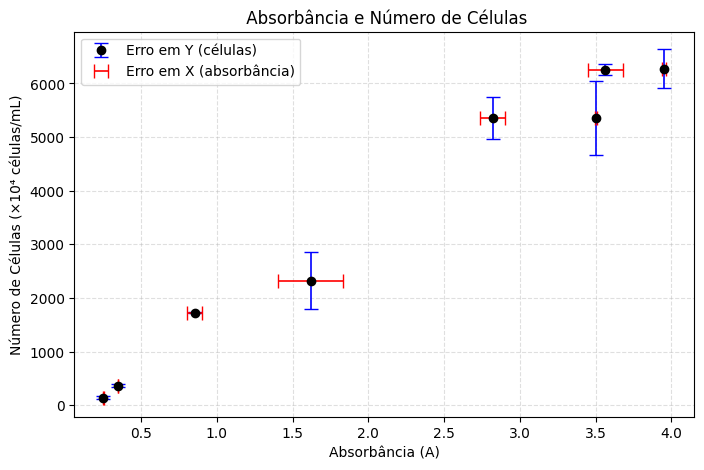

In [ ]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    media_absorbancia,
    media,
    yerr=2*desvio,
    fmt='o',             # desenha pontos
    color="black",       # cor dos pontos
    ecolor="blue",       # cor das barras de erro em Y
    capsize=5,
    elinewidth=1.2,
    label="Erro em Y (células)"
)

# --- Barras de erro no eixo X (VERMELHO) ---
plt.errorbar(
    media_absorbancia,
    media,
    xerr=2*desvio_absorbancia,
    fmt='none',          # NÃO desenha ponto nem linha
    ecolor="red",        # cor das barras de erro em X
    capsize=5,
    elinewidth=1.2,
    label="Erro em X (absorbância)"
)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.title(" Absorbância e Número de Células")
plt.xlabel("Absorbância (A)")
plt.ylabel(r"Número de Células (×10⁴ células/mL)")

plt.show()


In [ ]:
# Verificação do Data-Frame

x_dias = pontos_células_I[:, 0]
# --- criar DataFrames para inspecionar (opcional) ---
cultivo = np.column_stack((x_dias, media, desvio))
df_cultivo = pd.DataFrame(cultivo, columns=["dias", "media_celulas", "desvio_celulas"]).round(2)

df_abs = pd.DataFrame({
    "dias": x_dias,
    "media_absorbancia": media_absorbancia,
    "desvio_absorbancia": desvio_absorbancia
}).round(3)

print(df_cultivo)
print("--------------------------")
print(df_abs)

   dias  media_celulas  desvio_celulas
0   1.0         140.33           13.89
1   3.0         368.00           14.85
2   5.0        1728.33            2.36
3   7.0        2320.00          265.55
4   9.0        5355.00          192.48
5  11.0        6258.33           51.37
6  13.0        5356.67          348.93
7  15.0        6275.00          181.43
--------------------------
   dias  media_absorbancia  desvio_absorbancia
0   1.0              0.251               0.002
1   3.0              0.346               0.000
2   5.0              0.854               0.026
3   7.0              1.619               0.107
4   9.0              2.820               0.041
5  11.0              3.565               0.057
6  13.0              3.503               0.002
7  15.0              3.951               0.007


# Método dos mínimos Quadrados

$y = ab^x$

$z = ln (y) = ln (ab^x)$

$z = ln (y) = ln (a) + ln (b^x)$

$z = ln (y) = ln (a) + x. ln (b)$

$a_1 = ln(a)$

$a_2 = ln (b)$


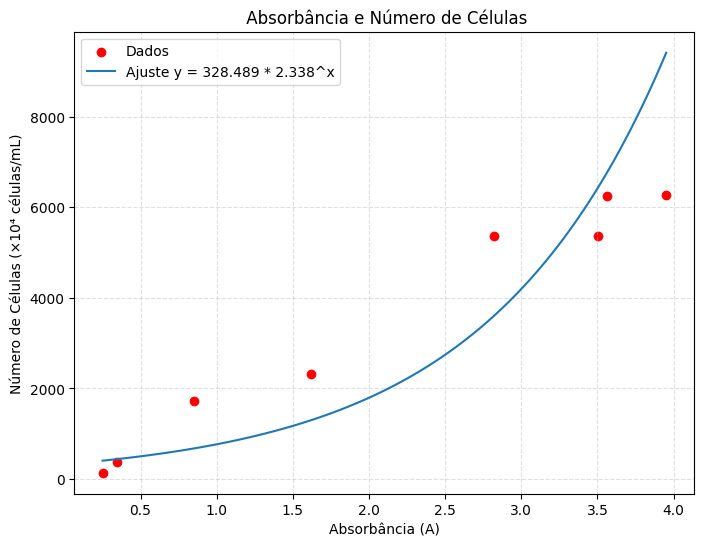

In [ ]:
z = np.log(media)
x = media_absorbancia

X = np.array(x)
Y = z
n = len(X)

A = np.vstack([np.ones(n), X]).T  # cria um vetor de n elementos valendo 1 e coloca os valores de x da distribuição ao lado dele

coef = np.linalg.solve(A.T @ A, A.T @ Y)    # coef = [a0, a1]
a1, a2 = coef[0], coef[1]

a = math.exp(a1)
b = math.exp(a2)

#Para comparação do erro futuro
a_7_a = a
b_7_a = b

# Avaliando em vários pontos
xv = np.linspace(min(x), max(x), 100)

y_fit = a*b**xv


# Plotando
plt.figure(figsize=(8, 6))

plt.scatter(media_absorbancia, media, color='red', label='Dados')
plt.plot(xv, y_fit, label=f"Ajuste y = {a:.3f} * {b:.3f}^x")
#Adiciona uma grade
plt.grid(True, linestyle='--', alpha=0.6)


plt.legend()

plt.grid(True, linestyle='--', alpha=0.4)
plt.title(" Absorbância e Número de Células")
plt.xlabel("Absorbância (A)")
plt.ylabel(r"Número de Células (×10⁴ células/mL)")

plt.show()


Percebemos que não ficou a melhor das curvas para ser ajustada.

$y = ax^b$

$z = ln (y) = ln (ax^b)$

$z = ln (y) = ln (a) + ln (x^b)$

$z = ln (y) = ln (a) + b. ln (x)$

$a_1 = ln(a)$

$a_2 = b $

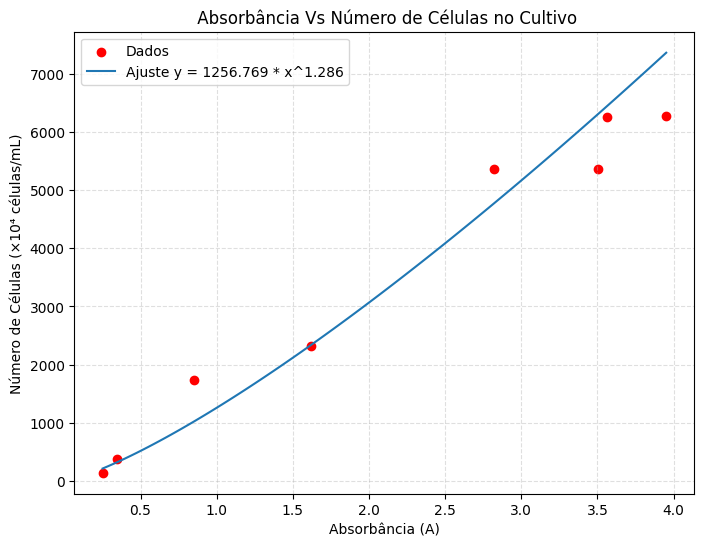

In [ ]:


z = np.log(media)

x = np.log(media_absorbancia)

X = np.array(x)
Y = z
n = len(X)

A = np.vstack([np.ones(n), X]).T  # cria um vetor de n elementos valendo 1 e coloca os valores de x da distribuição ao lado dele

coef = np.linalg.solve(A.T @ A, A.T @ Y)    # coef = [a0, a1]
a1, a2 = coef[0], coef[1]

a = math.exp(a1)
b = a2

# Avaliando em vários pontos
xv = np.linspace(min(media_absorbancia), max(media_absorbancia), 100)

y_fit = a*(xv)**b


# Plotando
plt.figure(figsize=(8, 6))

plt.scatter(media_absorbancia, media, color='red', label='Dados')
plt.plot(xv, y_fit, label=f"Ajuste y = {a:.3f} * x^{b:.3f}")
#Adiciona uma grade
plt.grid(True, linestyle='--', alpha=0.6)

plt.grid(True, linestyle='--', alpha=0.4)
plt.title(" Absorbância Vs Número de Células no Cultivo")
plt.xlabel("Absorbância (A)")
plt.ylabel(r"Número de Células (×10⁴ células/mL)")

plt.legend()
plt.show()

# Equação encontrada pelo método dos Mínimos Quadrados

$f(x) = y = 1256,769.x^{1,286}$

# ERRO pela função encontrada

$$
\text{MSE} \;=\; \frac{\sum_{i=1}^{n} \left(\text{celulas}_i - \text{y}_i\right )^2/ n}{\sum_{i=1}^{n} \text{celulas}_i / n}
$$

sendo:

n: Número de dias em que houve contagem de células. \
i: dia em que houve contagem de células \
$celulas_i$: número de células na contagem do dia $i$ \
$y_i$: células encontradas na minha função ajustada $1256.769*x^{1.286}$ \
x: absorbância medida no dia $i$

In [ ]:
y_fit


array([ 212.293241  ,  321.22932925, 1025.31619033, 2336.5022219 ,
       4769.80186887, 6448.8065502 , 6305.65442764, 7361.48518555])

In [ ]:
media

array([ 140.33333333,  368.        , 1728.33333333, 2320.        ,
       5355.        , 6258.33333333, 5356.66666667, 6275.        ])

In [ ]:
# Função ajustada
def f_ajustada(xv):
     xv = np.array(xv)
     return a*xv**b


# Avalia ajuste e erro em relação a y = ab^x
y_fit = f_ajustada(media_absorbancia)
mse = np.sum((media - y_fit)**2)/np.sum(media)


print(f"MSE_para curva y = {a:.3f} * x^{b:.3f} = {mse:.6f}")

MSE_para curva y = 1256.769 * x^1.286 = 106.527278


# Testando a Função para uma absrobância de 2.2

In [ ]:
teste = 2.2

y_x = f_ajustada(teste)

print(f"A quantidade de células com absorbância {teste} é aproximadamente y(x) = {y_x:.2f} × 10^4 células/mL")


A quantidade de células com absorbância 2.2 é aproximadamente y(x) = 3465.63 × 10^4 células/mL


# Referências

ASSOCIAÇÃO BRASILEIRA DE NORMAS TÉCNICAS. NBR 12648: Ecotoxicologia aquática – Toxicidade crônica – Método de ensaio com algas (Chlorophyceae). Rio de Janeiro, 2004.

BRACHT, ADELAR; ISHII-IWAMOTO, E.L; Métodos de Laboratório em bioquímica. Primeira Edição, ISBN 85-204-1338-2. Capítulo 2. 2003

FINGER, GUSTAVO STRAUCH WILIN. Aumento de biomassa de microalgas cultivadas em fotobiorreatores pela injeção de emissões de grupo motogerador diesel. 139f.

Dissertação de Mestrado em Engenharia e Ciência dos Materiais, Setor de Tecnologia da Universidade Federal do Paraná. 2016.

Ruggiero, M. A. G., & da Rocha Lopes, V. L. (1998). Cálculo numérico: aspectos teóricos e computacionais. Pearson/Makron. Capítulo 6

SANTOS, BEATRIZ. Estratégias para aumentar a produtividade de biomassa de microalgas com carbono orgânico. 104 f. Dissertação de Mestrado em Engenharia e Ciência dos Materiais, Setor de Tecnologia da Universidade Federal do Paraná. 2016.
